> 逻辑斯蒂回归和线性模型的明显区别是在线性模型的后面，添加了激活函数(非线性变换)

> 衡量分布之间的差异：KL散度，cross-entropy交叉熵

交叉熵损失（Cross-Entropy Loss）是分类问题中最常用的损失函数，它衡量模型预测的概率分布与真实标签分布之间的差异。下面从信息论基础、公式推导、与极大似然的关系，以及 PyTorch 中的实现等方面详细讲解。

---

## 1. 信息论基础

### 熵（Entropy）
对于离散随机变量 \($X$\)，其概率分布为 \($p(x)$\)，熵定义为：

\[
$H(p) = -\sum_x p(x) \log p(x)$
\]

熵表示分布的不确定性。熵越大，分布越均匀。

### KL 散度（Kullback-Leibler Divergence）
KL 散度衡量两个分布 \($p$\) 和 \($q$\) 之间的差异：

\[
$D_{KL}(p \| q) = \sum_x p(x) \log \frac{p(x)}{q(x)} = H(p,q) - H(p)$
\]

其中 \($H(p,q)$\) 是交叉熵。

### 交叉熵（Cross-Entropy）
交叉熵定义为：

\[
$H(p,q) = -\sum_x p(x) \log q(x)$
\]

当 \($p$\) 是真实分布，\($q$\) 是预测分布时，交叉熵等于 \($H(p) + D_{KL}(p \| q)$\)。由于 \($H(p)$\) 对固定数据来说是常数，最小化交叉熵等价于最小化 KL 散度，即让预测分布 \($q$\) 逼近真实分布 \($p$\)。

---

## 2. 交叉熵损失在分类中的应用

### 二分类问题
对于二分类，真实标签 \($y \in \{0,1\}$\)，模型输出一个概率 \($p = P(y=1 \mid x)$\)（通常由 sigmoid 函数将 logit 映射到 (0,1)）。交叉熵损失为：

\[
$\mathcal{L} = -\left[ y \log p + (1-y) \log(1-p) \right]$
\]

- 当 \($y=1$\) 时，损失为 \($-\log p$\)，鼓励 \($p$\) 接近 1。
- 当 \($y=0$\) 时，损失为 \($-\log(1-p)$\)，鼓励 \($p$\) 接近 0。

### 多分类问题
对于 \($C$\) 类分类，真实标签为 one-hot 向量 \($y = [y_1, y_2, ..., y_C]$\)，其中只有一个 \($y_k=1$\)，其余为 0。模型输出经过 softmax 得到类别概率分布 \($q = [q_1, q_2, ..., q_C]$\)，其中 \($q_i = \frac{e^{z_i}}{\sum_{j=1}^C e^{z_j}}$\)，\($z_i$\) 是最后一层的 logits（未归一化的得分）。交叉熵损失为：

\[
$\mathcal{L} = -\sum_{i=1}^C y_i \log q_i$
\]

由于 \($y$\) 是 one-hot，只有真实类别 \($c$\) 对应项非零，因此：

\[
$\mathcal{L} = -\log q_c$
\]

即只关心模型对正确类别的预测概率，鼓励其尽可能大。

---

## 3. 与极大似然估计的关系

分类模型的常用目标是最大化训练数据的似然。假设数据独立同分布，对数似然为：

\[
$\log \mathcal{L} = \sum_{n=1}^N \log P(y_n \mid x_n)$
\]

对于单个样本，在概率模型中：
- 二分类：\($P(y \mid x) = p^y (1-p)^{1-y}$\)
- 多分类：\($P(y \mid x) = \prod_{i=1}^C q_i^{y_i}$\)

取负对数，恰好就是交叉熵损失。因此，**最小化交叉熵等价于最大化对数似然**。

---

## 4. PyTorch 中的交叉熵实现

PyTorch 提供了多种与交叉熵相关的损失函数，区别在于输入形式和是否内置激活函数。

### 4.1 `nn.CrossEntropyLoss`
最常用的多分类损失，**内置了 softmax**。输入要求：
- **输入**：模型原始输出 logits（形状 `(N, C)`，未经过 softmax）。
- **标签**：类别索引（形状 `(N,)`，值为 `0, 1, ..., C-1`），而不是 one-hot 向量。

内部计算步骤：
1. 对 logits 应用 softmax 得到概率分布。
2. 取正确类别的负对数作为损失，并求平均（或求和）。

示例：
```python
import torch
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()
logits = torch.randn(3, 5)        # 3个样本，5个类别
labels = torch.tensor([1, 0, 4])  # 真实类别索引
loss = loss_fn(logits, labels)    # 输出一个标量
```

### 4.2 `nn.BCEWithLogitsLoss`
用于二分类，**内置了 sigmoid**。输入：
- 输入：logits（形状 `(N,)` 或 `(N, 1)`）。
- 标签：二值化标签（0 或 1），形状与输入相同。

内部组合了 sigmoid 和二进制交叉熵，数值稳定性优于单独使用 `sigmoid` + `BCELoss`。

### 4.3 `nn.BCELoss`
需要先手动对 logits 应用 sigmoid，然后输入概率值。不建议直接使用，因为数值不稳定。

### 4.4 类权重与样本权重
`CrossEntropyLoss` 支持 `weight` 参数（类别权重）和 `reduction` 参数（`'mean'`、`'sum'`、`'none'`），用于处理类别不平衡问题。

---

## 5. 数值计算示例

假设多分类问题，类别数 C=3，一个样本的 logits 为 `[2.0, 1.0, 0.1]`，真实标签为类别 0。

**步骤1**：计算 softmax

\[
$q_0 = \frac{e^{2.0}}{e^{2.0}+e^{1.0}+e^{0.1}} \approx \frac{7.389}{7.389+2.718+1.105} \approx 0.659$
\]

\[
$q_1 \approx 0.242, \quad q_2 \approx 0.099$
\]

**步骤2**：交叉熵损失

\[
$\mathcal{L} = -\log q_0 = -\log 0.659 \approx 0.417$
\]

在 PyTorch 中：

```python
logits = torch.tensor([[2.0, 1.0, 0.1]])
labels = torch.tensor([0])
loss = nn.CrossEntropyLoss()(logits, labels)
print(loss.item())  # 约 0.417
```

---

## 6. 注意事项

- **数值稳定性**：`CrossEntropyLoss` 内部使用 `log_softmax` 与 `nll_loss` 组合，避免直接计算 softmax 后再取 log 导致的数值下溢。
- **标签格式**：多分类标签必须是 0 到 C-1 的整数索引，而不是 one-hot 向量。
- **梯度**：交叉熵损失对 logits 的梯度形式为 \(q_i - y_i\)（对于正确类别减 1，其他类减 0），这正是 softmax 后与 one-hot 标签的差值，便于反向传播。
- **多标签分类**：当每个样本可能属于多个类别时（多标签分类），不能使用 `CrossEntropyLoss`，而应使用 `BCEWithLogitsLoss` 并将标签视为多热向量。

---

## 7. 总结

- 交叉熵损失通过惩罚预测概率与真实分布的差异，引导模型对正确类别输出高概率。
- 它等价于最大化对数似然，具有坚实的统计基础。
- PyTorch 提供的 `CrossEntropyLoss` 将 softmax 与负对数似然合并，使用方便且数值稳定。
- 理解交叉熵的数学原理和实现细节，有助于调试分类模型和选择正确的损失函数。

如果你在具体使用中遇到问题（如类别不平衡、多标签分类等），可以进一步探讨。

In [1]:
import torch
# import torch.nn.functional as F
 
# prepare dataset
x_data = torch.Tensor([[1.0], [2.0], [3.0]])
y_data = torch.Tensor([[0], [0], [1]])
 
#design model using class
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1,1)
 
    def forward(self, x):
        # y_pred = F.sigmoid(self.linear(x))
        y_pred = torch.sigmoid(self.linear(x))    # 经过线性层后再经过非线性层 sigmoid 函数
        return y_pred
model = LogisticRegressionModel()
 
# construct loss and optimizer
# 默认情况下，loss会基于element平均，如果size_average=False的话，loss会被累加。
criterion = torch.nn.BCELoss(size_average = False)   # 使用二元交叉熵(BCE)损失函数
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)
 
# training cycle forward, backward, update
for epoch in range(1000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
print('w = ', model.linear.weight.item())
print('b = ', model.linear.bias.item())
 
x_test = torch.Tensor([[4.0]])
y_test = model(x_test)
print('y_pred = ', y_test.data)

/environment/miniconda3/envs/pytorch_learning/lib/python3.10/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


0 3.991103172302246
1 3.9044759273529053
2 3.8200302124023438
3 3.737832546234131
4 3.657944440841675
5 3.5804190635681152
6 3.505307912826538
7 3.43265438079834
8 3.3624956607818604
9 3.2948598861694336
10 3.229769468307495
11 3.167235851287842
12 3.1072635650634766
13 3.049846649169922
14 2.9949707984924316
15 2.9426136016845703
16 2.89274263381958
17 2.845318078994751
18 2.800290584564209
19 2.7576065063476562
20 2.717203378677368
21 2.6790120601654053
22 2.642961025238037
23 2.6089725494384766
24 2.5769667625427246
25 2.5468597412109375
26 2.5185670852661133
27 2.4920032024383545
28 2.4670815467834473
29 2.4437172412872314
30 2.4218244552612305
31 2.401320695877075
32 2.382124900817871
33 2.3641581535339355
34 2.347343921661377
35 2.331608533859253
36 2.316882610321045
37 2.303098440170288
38 2.290191888809204
39 2.2781026363372803
40 2.2667737007141113
41 2.256150722503662
42 2.246182680130005
43 2.2368223667144775
44 2.228024482727051
45 2.219748020172119
46 2.2119531631469727
47

/environment/miniconda3/envs/pytorch_learning/lib/python3.10/site-packages/torch/nn/modules/loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


0 2.9250173568725586
1 2.8869004249572754
2 2.8502941131591797
3 2.815181016921997
4 2.7815394401550293
5 2.749345064163208
6 2.7185699939727783
7 2.6891837120056152
8 2.6611533164978027
9 2.6344432830810547
10 2.6090164184570312
11 2.5848331451416016
12 2.5618526935577393
13 2.5400326251983643
14 2.5193302631378174
15 2.499701738357544
16 2.481102466583252
17 2.4634885787963867
18 2.4468154907226562
19 2.4310390949249268
20 2.4161159992218018
21 2.402003526687622
22 2.3886594772338867
23 2.3760428428649902
24 2.364114284515381
25 2.352834463119507
26 2.3421664237976074
27 2.3320741653442383
28 2.322523355484009
29 2.313480854034424
30 2.304915189743042
31 2.2967960834503174
32 2.289095163345337
33 2.281784772872925
34 2.2748398780822754
35 2.268235921859741
36 2.2619495391845703
37 2.255959987640381
38 2.250246047973633
39 2.2447893619537354
40 2.2395715713500977
41 2.2345762252807617
42 2.2297871112823486
43 2.2251901626586914
44 2.220771312713623
45 2.216517686843872
46 2.2124176025

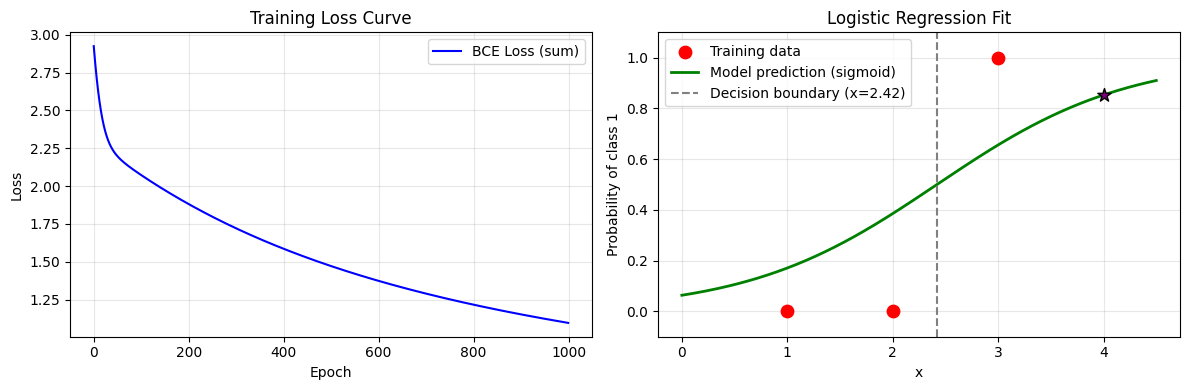

Trained parameters: w = 1.1125, b = -2.6915
Decision boundary at x = 2.4193
Prediction for x=4.0: 0.8530 (probability of class 1)


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
# import torch.nn.functional as F
 
# prepare dataset
x_data = torch.Tensor([[1.0], [2.0], [3.0]])
y_data = torch.Tensor([[0], [0], [1]])
 
#design model using class
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1,1)
 
    def forward(self, x):
        # y_pred = F.sigmoid(self.linear(x))
        y_pred = torch.sigmoid(self.linear(x))    # 经过线性层后再经过非线性层 sigmoid 函数
        return y_pred
model = LogisticRegressionModel()
 
# construct loss and optimizer
# 默认情况下，loss会基于element平均，如果size_average=False的话，loss会被累加。
criterion = torch.nn.BCELoss(size_average = False)   # 使用二元交叉熵(BCE)损失函数
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

losses = []
# training cycle forward, backward, update
for epoch in range(1000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    losses.append(loss.item())
    print(epoch, loss.item())
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
print('w = ', model.linear.weight.item())
print('b = ', model.linear.bias.item())

# ================= 可视化 =================

# 1. 绘制损失曲线
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses, label='BCE Loss (sum)', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(alpha=0.3)
plt.legend()

# 2. 绘制数据点与模型预测的 sigmoid 曲线
# 创建密集的 x 值用于绘制模型输出
x_plot = torch.linspace(0, 4.5, 200).reshape(-1, 1)
with torch.no_grad():
    y_plot = model(x_plot).numpy()   # 模型输出概率

# 原始数据点
x_np = x_data.numpy().flatten()
y_np = y_data.numpy().flatten()

plt.subplot(1, 2, 2)
plt.scatter(x_np, y_np, color='red', s=80, label='Training data', zorder=5)
plt.plot(x_plot.numpy(), y_plot, color='green', linewidth=2, label='Model prediction (sigmoid)')

# 绘制决策边界（概率 = 0.5 对应的 x 值）
# 解方程 sigmoid(w*x + b) = 0.5  => w*x + b = 0 => x = -b/w
w = model.linear.weight.item()
b = model.linear.bias.item()
decision_x = -b / w
plt.axvline(x=decision_x, color='gray', linestyle='--', linewidth=1.5, label=f'Decision boundary (x={decision_x:.2f})')

plt.xlabel('x')
plt.ylabel('Probability of class 1')
plt.title('Logistic Regression Fit')
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.3)
plt.legend()
 
# 可选：标注测试点 x=4 的预测概率
x_test = torch.tensor([[4.0]])
y_test = model(x_test).item()
plt.scatter(4.0, y_test, color='purple', s=100, marker='*', edgecolors='black', label=f'Test x=4 → {y_test:.3f}', zorder=6)

plt.tight_layout()
plt.show()

# 打印模型参数和测试结果
print(f'Trained parameters: w = {w:.4f}, b = {b:.4f}')
print(f'Decision boundary at x = {decision_x:.4f}')
print(f'Prediction for x=4.0: {y_test:.4f} (probability of class 1)')